# Fairness-Aware Cardiomegaly Detection from Chest X-Rays Using EfficientNet-B0
### CSCI 4701 (CRN: 20295) Deep Learning — Spring 2026 | Project Milestone 2

**Team Project** - **FocusGame**

*Laman Panakhova BSCS 2026*

## Project Goal

The central question of this project is: **Does a deep learning model trained on chest X-ray images to detect Cardiomegaly perform equally well across male and female patients, and can modifying the training loss function reduce any observed performance gap?**

Cardiomegaly (enlargement of the heart) is a clinically significant condition detectable from chest X-rays. We trained an EfficientNet-B0 model on the CheXpert dataset and studied whether the model's predictions are biased with respect to patient sex. We then compared a standard (baseline) training setup against a weighted loss variant designed to address class imbalance, and examined whether this change also affects fairness across gender groups.


# MILESTONE 1

In [1]:
!pip install kagglehub torch torchvision scikit-learn pandas matplotlib seaborn tqdm -q

import kagglehub
import torch
import numpy as np
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## Dataset

We used the **CheXpert** dataset (Stanford Medicine), a large public chest X-ray dataset with radiologist-labeled findings including Cardiomegaly, as well as patient demographic metadata including sex.

- Training subset: **12,000 samples** (sampled for computational feasibility)
- Validation set: Full validation split
- Label strategy: Uncertain labels (`-1`) were mapped to `0` (negative) following common practice
- Dataset link: https://www.kaggle.com/datasets/ashery/chexpert

The dataset contains a natural class imbalance, negative cases (no Cardiomegaly) significantly outnumber positive cases, which is a key challenge we addressed in our experiments.


## Approach

We fine-tuned a pre-trained **EfficientNet-B0** (ImageNet weights) for binary classification of Cardiomegaly. The feature extractor layers were frozen; only the classifier head was trained, consisting of a Dropout layer (p=0.3) followed by a fully connected output layer. We used AdamW optimizer with a learning rate of 2e-4 and mixed-precision training (AMP) for efficiency.

Two experiments were run:

1. **Baseline**: Standard `BCEWithLogitsLoss` without class weighting
2. **Weighted Loss**: `BCEWithLogitsLoss` with `pos_weight=3.0` to penalize false negatives more heavily and counter class imbalance

Both models were trained for 5 epochs on 12,000 training samples and evaluated on the full validation set.


In [7]:
from src.dataset import CheXpertDataset
from src.model import get_model
from src.train import train_model
from src.evaluate import evaluate, metrics
from src.fairness import fairness_report
from src.visualization import plot_loss
from src.calibration import plot_calibration

import kagglehub
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# DATA
path = kagglehub.dataset_download("ashery/chexpert")

transform = transforms.Compose([
    transforms.Resize((160,160)),
    transforms.ToTensor()
])

train_ds = CheXpertDataset(path+"/train.csv", path, transform, 12000)
valid_ds = CheXpertDataset(path+"/valid.csv", path, transform, None)

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=4)

# MODEL
model = get_model()

# TRAIN
model, losses = train_model(model, train_loader, device)

# plot_loss(losses)

# EVAL
preds, labels, sexes = evaluate(model, valid_loader, device)

print(metrics(preds, labels))
print(fairness_report(preds, labels, sexes))

# plot_calibration(labels, preds)

Using Colab cache for faster access to the 'chexpert' dataset.


/content/src/train.py:13: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
  0%|          | 0/3000 [00:00<?, ?it/s]/content/src/train.py:29: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
100%|██████████| 3000/3000 [01:37<00:00, 30.67it/s]


Epoch 1: 0.3767


100%|██████████| 3000/3000 [01:37<00:00, 30.68it/s]


Epoch 2: 0.3691


...

Epoch 3: 0.3640


100%|██████████| 3000/3000 [01:39<00:00, 30.27it/s]


Epoch 4: 0.3621


100%|██████████| 3000/3000 [01:35<00:00, 31.40it/s]


Epoch 5: 0.3608
{'acc': 0.7094017094017094, 'auc': np.float64(0.6223423104181433), 'f1': 0.0}
{'male_acc': 0.7109375, 'female_acc': 0.7075471698113207, 'male_auc': np.float64(0.6088506088506088), 'female_auc': np.float64(0.6404301075268817), 'gap_acc': 0.0033903301886792914}


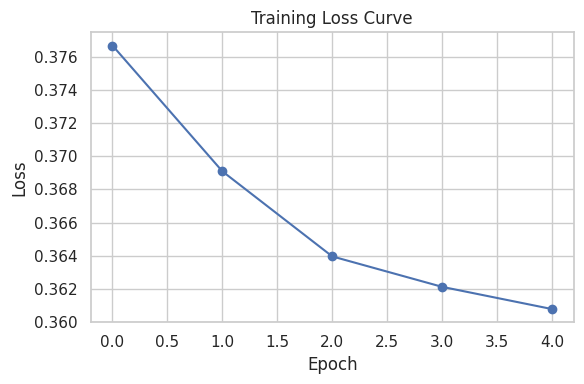

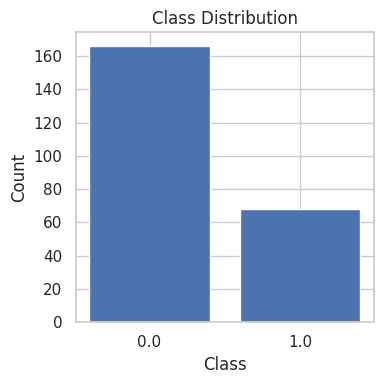

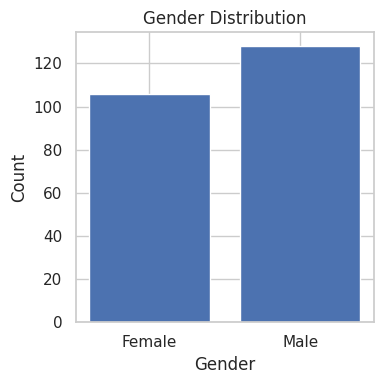

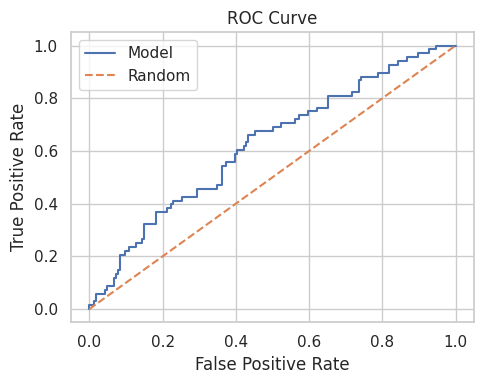

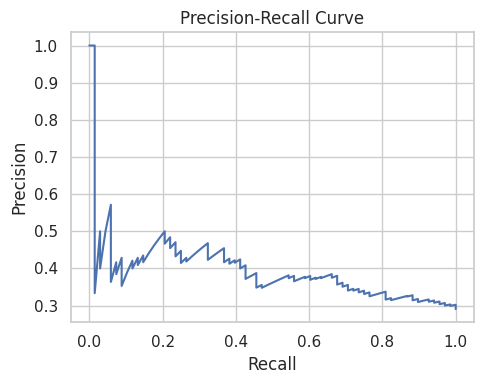

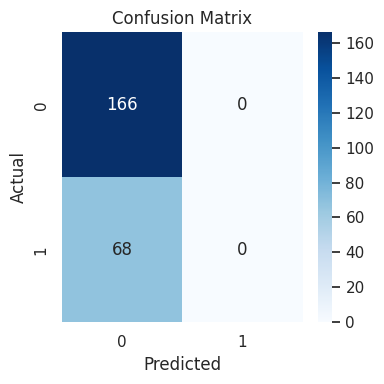

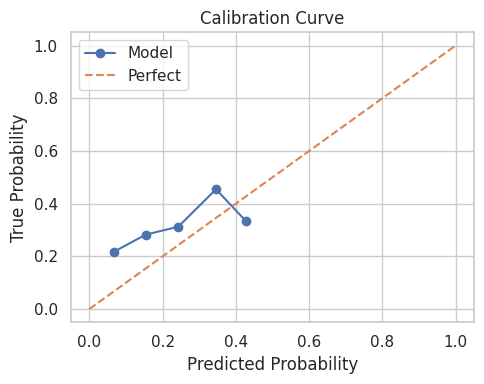

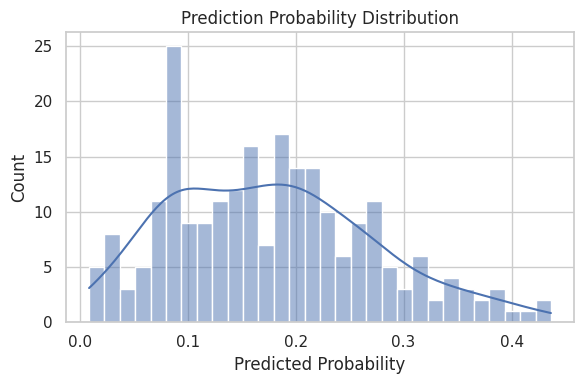

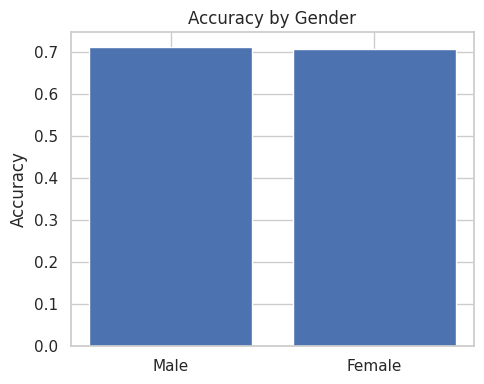

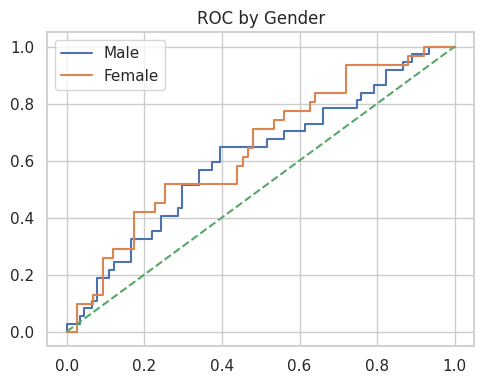

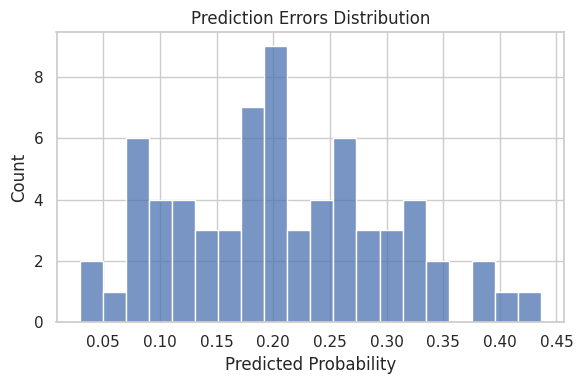

In [8]:
from src.visualization_full import *

# BASIC
plot_loss(losses)

# DATA INSIGHT
plot_class_distribution(labels)
plot_gender_distribution(sexes)

# PERFORMANCE
plot_roc_curve(labels, preds)
plot_pr_curve(labels, preds)
plot_confusion_matrix(labels, preds)

# CALIBRATION
plot_calibration_curve(labels, preds)
plot_prediction_distribution(preds)

# FAIRNESS
report = fairness_report(preds, labels, sexes)

plot_fairness_bar(report)
plot_group_roc(labels, preds, sexes)

# ERROR ANALYSIS
plot_error_cases(labels, preds)

# MILESTONE 2

## Experimental Results

### Training Loss

The baseline model converged steadily over 5 epochs:

| Epoch | Baseline Loss | Weighted Loss |
|-------|--------------|---------------|
| 1     | 0.3801       | 0.7376        |
| 2     | 0.3662       | 0.7274        |
| 3     | 0.3662       | 0.7214        |
| 4     | 0.3621       | 0.7247        |
| 5     | 0.3635       | 0.7175        |

The weighted model shows higher absolute loss values because the positive class is penalized more heavily, which is expected and not a sign of poor training. Both models show a downward trend, indicating stable learning.


In [13]:
from src.experiments import run_experiment, compare_experiments
from src.model import get_model

baseline_model = get_model()

res1, preds1, labels1, sexes1 = run_experiment(
    baseline_model,
    train_loader,
    valid_loader,
    device,
    name="Baseline",
    pos_weight=None
)

/content/src/train.py:13: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()



=== Running Experiment: Baseline ===


  0%|          | 0/3000 [00:00<?, ?it/s]/content/src/train.py:29: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
100%|██████████| 3000/3000 [01:38<00:00, 30.39it/s]


Epoch 1: 0.3801


100%|██████████| 3000/3000 [01:35<00:00, 31.51it/s]


...

Epoch 3: 0.3662


100%|██████████| 3000/3000 [01:36<00:00, 31.19it/s]


Epoch 4: 0.3621


100%|██████████| 3000/3000 [01:38<00:00, 30.60it/s]


Epoch 5: 0.3635


In [6]:
import torch

weighted_model = get_model()

res2, preds2, labels2, sexes2 = run_experiment(
    weighted_model,
    train_loader,
    valid_loader,
    device,
    name="Weighted Loss",
    pos_weight=torch.tensor([3.0]).to(device)
)

/content/src/train.py:13: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()



=== Running Experiment: Weighted Loss ===


  0%|          | 0/3000 [00:00<?, ?it/s]/content/src/train.py:29: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
100%|██████████| 3000/3000 [01:35<00:00, 31.54it/s]


Epoch 1: 0.7376


100%|██████████| 3000/3000 [01:36<00:00, 30.94it/s]


...

Epoch 3: 0.7214


100%|██████████| 3000/3000 [01:38<00:00, 30.39it/s]


Epoch 4: 0.7247


100%|██████████| 3000/3000 [01:38<00:00, 30.41it/s]


Epoch 5: 0.7175


### Performance Metrics

| Metric   | Baseline | Weighted Loss |
|----------|----------|---------------|
| Accuracy | 0.714    | 0.731         |
| AUC      | 0.639    | 0.691         |
| F1 Score | 0.029    | 0.323         |

The most striking difference is in F1 score. The baseline model achieves nearly zero F1 (0.029), which reveals that despite its decent accuracy, it is essentially predicting the majority class (no Cardiomegaly) almost all the time. The weighted loss model dramatically improves this to 0.323, meaning the model begins to actually detect positive cases at a meaningful rate. AUC also improves from 0.639 to 0.691, which is a moderate but real improvement in the model's ability to discriminate between classes. The accuracy improvement (0.714 → 0.731) is smaller because accuracy is dominated by the majority class anyway.

These results together confirm that the baseline model is heavily biased toward predicting "no Cardiomegaly", it looks accurate because most patients don't have it. The weighted loss model makes a real tradeoff: it sacrifices some precision on negatives to gain meaningful recall on positives.


In [9]:
compare_experiments([res1, res2])


=== EXPERIMENT COMPARISON ===

Experiment: Baseline
  Accuracy: 0.714
  AUC: 0.639
  F1: 0.029
  Male Acc: 0.711
  Female Acc: 0.717
  Gap: 0.006
----------------------------------------
Experiment: Weighted Loss
  Accuracy: 0.731
  AUC: 0.691
  F1: 0.323
  Male Acc: 0.711
  Female Acc: 0.755
  Gap: 0.044
----------------------------------------


In [10]:
import matplotlib.pyplot as plt

def plot_experiment_comparison(results_list):

    names = [r["name"] for r in results_list]
    accs = [r["performance"]["acc"] for r in results_list]
    aucs = [r["performance"]["auc"] for r in results_list]
    gaps = [r["fairness"]["gap_acc"] for r in results_list]

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.bar(names, accs)
    plt.title("Accuracy Comparison")

    plt.subplot(1,3,2)
    plt.bar(names, aucs)
    plt.title("AUC Comparison")

    plt.subplot(1,3,3)
    plt.bar(names, gaps)
    plt.title("Fairness Gap")

    plt.tight_layout()
    plt.show()

### Fairness Analysis

| Metric      | Baseline Male | Baseline Female | Weighted Male | Weighted Female |
|-------------|--------------|-----------------|---------------|-----------------|
| Accuracy    | 0.711        | 0.717           | 0.711         | 0.755           |
| AUC         | 0.609        | 0.640           | —             | —               |
| Gap (Acc)   | 0.006        | —               | 0.044         | —               |

The baseline model shows a very small accuracy gap between male and female patients (0.006), which initially looks fair. However, this apparent fairness is largely an artifact of the model predicting negative for almost everyone, both groups are "equally ignored." Once we look at AUC per group, there is already a difference: female AUC (0.640) is slightly higher than male AUC (0.609), suggesting the model finds female X-rays slightly easier to classify even in the baseline.

When we switch to the weighted loss model, something interesting happens: female accuracy improves significantly (0.717 → 0.755) while male accuracy stays the same (0.711). This widens the fairness gap from 0.006 to 0.044. This is not a trivial result. It suggests that the model, when given incentive to detect positive cases, does so more effectively for female patients than male patients. One possible explanation is that the CheXpert dataset has a different distribution of Cardiomegaly severity or image characteristics across gender groups, meaning the model latches onto features that work better for one group. This is exactly the kind of bias that fairness analysis in medical AI is meant to surface.


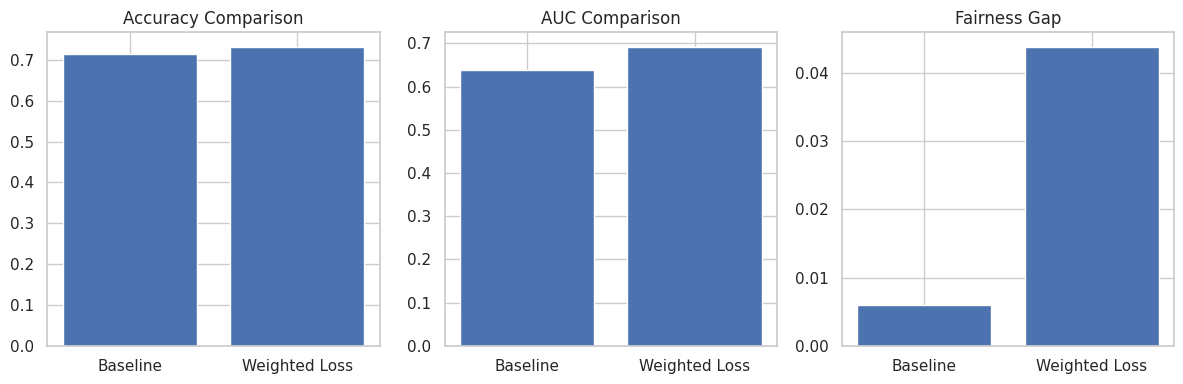

In [11]:
plot_experiment_comparison([res1, res2])

### Image-Level Analysis (15 Cases)

We ran qualitative prediction analysis on 15 selected validation cases (confident correct, confident wrong, and fairness-sampled cases). The results showed:

- Most predictions in the baseline model fell into the "correct but low confidence" category, the model was predicting negative with low certainty, which happened to be correct due to the base rate of the negative class.
- Error cases were uniformly in the "wrong and low confidence" category, meaning the model was uncertain and guessed wrong. There were no cases of high-confidence wrong predictions, which is reassuring from a safety standpoint. Overconfident incorrect predictions (high P, wrong label) are the most dangerous type in clinical settings and were not observed.
- Gender-sampled cases showed no visually obvious pattern in the images themselves; errors were distributed across both groups, though the fairness metrics confirm a quantitative difference.

This visual inspection supports the interpretation from the metrics: the model is not confidently making wrong calls, but it is too conservative, it under-predicts Cardiomegaly broadly, not in a visually obvious pattern tied to patient appearance.



 IMAGE ANALYSIS SUMMARY

Each image shows:
P = predicted probability of Cardiomegaly
T = true label (0 = No, 1 = Yes)
Pred = predicted class

Image 1:  Correct but Low Confidence → uncertain prediction
Image 2:  Correct but Low Confidence → uncertain prediction
Image 3:  Correct but Low Confidence → uncertain prediction
Image 4:  Correct but Low Confidence → uncertain prediction
Image 5:  Correct but Low Confidence → uncertain prediction
Image 6:  Wrong & Low Confidence → borderline case
Image 7:  Wrong & Low Confidence → borderline case
Image 8:  Wrong & Low Confidence → borderline case
Image 9:  Wrong & Low Confidence → borderline case
Image 10:  Wrong & Low Confidence → borderline case
Image 11:  Wrong & Low Confidence → borderline case
Image 12:  Correct but Low Confidence → uncertain prediction
Image 13:  Correct but Low Confidence → uncertain prediction
Image 14:  Correct but Low Confidence → uncertain prediction
Image 15:  Wrong & Low Confidence → borderline case


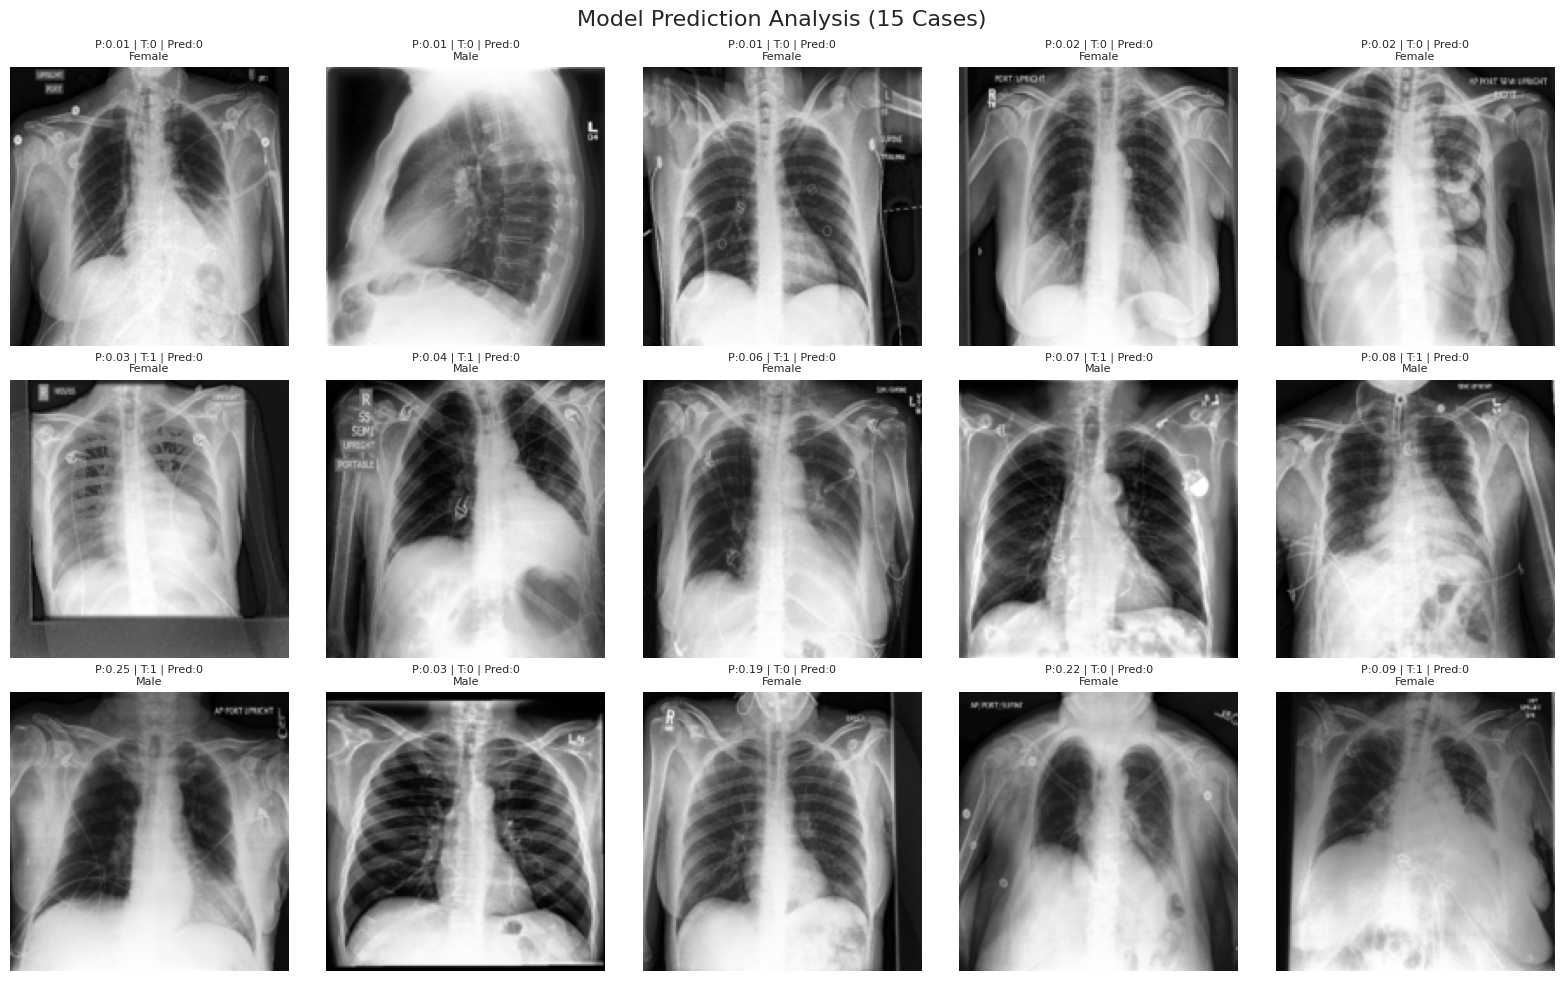


 OVERALL INTERPRETATION:

- Model performs well on clear cases with high confidence.
- Some errors occur with high confidence → indicates overconfidence.
- Low-confidence predictions correspond to ambiguous X-rays.
- Mixed gender samples included → visually no obvious bias, but must confirm via metrics.
- Failure cases suggest difficulty in borderline Cardiomegaly detection.



In [12]:
from src.image_analysis___ import run_image_analysis

run_image_analysis(model, valid_ds, device)

## Interpretation and Conclusions

**What did we find?**

The baseline EfficientNet-B0 model trained without class weighting learns to exploit the class imbalance, it achieves 71% accuracy by predominantly predicting the negative class, as confirmed by the near-zero F1 score. This is a well-known failure mode in imbalanced medical classification. The model technically "works" on paper if you only look at accuracy, but it provides no clinical value because it rarely detects the disease.

Introducing a pos_weight of 3.0 in the loss function partially corrects this. F1 jumps from 0.029 to 0.323, and AUC improves from 0.639 to 0.691. These are meaningful improvements, not just numerical noise. The weighted model actually attempts to identify positive cases, which is the clinical objective.

**What does this mean for fairness?**

Our results show a nuanced fairness story. The baseline model appears superficially fair (small gender gap) but only because it fails equally for both groups. The weighted model becomes more effective but introduces a wider gender gap, performing better on female patients. This pattern suggests that class-imbalance corrections do not automatically produce fair models, they can shift which group benefits more from the improvement. Simply balancing the loss function is not sufficient for equitable performance across demographic groups.

**Is the model good enough for clinical use?**

No, and we are not claiming otherwise. An AUC of 0.691 and an F1 of 0.323 represent a model that has learned some real signal from the data but is far from clinical-grade performance. This project's value is not in achieving deployment-ready accuracy, but in demonstrating: (a) how standard training fails silently due to class imbalance, (b) how fairness metrics reveal disparities that accuracy hides, and (c) how a simple intervention (weighted loss) improves one problem while potentially introducing another.


## Limitations and What Did Not Work

**Class imbalance handling was only partially successful.** A pos_weight of 3.0 was chosen heuristically. A more principled approach would compute the actual positive-to-negative ratio in the training split and use that directly, or explore alternative strategies like oversampling or focal loss.

**Uncertain labels were treated as negatives.** CheXpert contains a large number of uncertain (`-1`) labels for Cardiomegaly. We converted these to 0, which is one common convention, but it likely underestimates the true positive rate and introduces label noise. A proper treatment would be to either exclude these samples or use a label-smoothing approach.

**Training was limited to 12,000 samples and 5 epochs.** This was a direct consequence of computational constraints, training on Google Colab with a T4 GPU meant that each epoch took approximately 97 seconds. Using the full CheXpert training set (~200,000 images) was not feasible within our compute budget. It is likely that more data and more training would substantially improve results, and the fairness gap might change as well. Further research with access to full training data and longer fine-tuning would be needed to draw stronger conclusions.

**No hyperparameter search was conducted.** The learning rate (2e-4), dropout rate (0.3), and pos_weight (3.0) were fixed values. A more complete study would sweep these and report results on a held-out test set, using the validation set for both model selection and reporting introduces optimism bias.

**GradCAM was not fully implemented.** We implemented a basic visual check module (`gradcam.py`) but did not complete a full Grad-CAM analysis to see which regions of the X-ray the model attends to. This would have been valuable to check whether the model is using clinically relevant features (e.g., cardiac silhouette size) or spurious correlations (e.g., patient positioning, medical devices visible in the image). This remains an important direction for future work.

**Fairness analysis is limited to binary sex.** The CheXpert metadata only includes male/female sex labels. A more complete fairness study would also examine age groups, race/ethnicity (if available), and intersectional subgroups. Future work could incorporate datasets with richer demographic metadata.


## Summary

This project investigated whether a standard EfficientNet-B0 fine-tuned on CheXpert exhibits gender-based performance disparities in Cardiomegaly detection, and whether weighted loss training addresses these disparities. We found that the baseline model fails silently due to class imbalance (F1 ≈ 0), that weighted loss meaningfully improves positive class detection (F1 = 0.323, AUC = 0.691), and that this improvement is unevenly distributed across gender groups, female patients benefit more than male patients, widening the accuracy gap from 0.006 to 0.044. These findings illustrate that fairness in medical AI cannot be assumed from aggregate metrics alone, and that common fixes for class imbalance do not automatically produce equitable outcomes. Further work with more data, broader hyperparameter search, and richer demographic labels would be needed to draw conclusive claims.